# Covariance, Variance, and Distance-Based Clustering in Quant Finance

This notebook explains two core ideas in quantitative finance for beginners: **variance** and **covariance**. It then shows how we can use those relationships to group assets with **distance-based clustering**.

## What you will learn

- what variance means in plain language
- what covariance means and how it differs from correlation
- why covariance matters for portfolio diversification
- how to build a covariance matrix from return data
- how to convert similarity into distance and cluster assets

## Beginner intuition

A variance tells you how much one asset tends to move around. A covariance tells you whether two assets tend to move together. Once you know which assets move similarly, you can group them into clusters and better understand portfolio structure.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

np.random.seed(42)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 11

## 1. Variance — How Much One Asset Moves Around

### Formal idea

For a return series $r_t$, variance measures how far returns tend to spread out around their average value:

$$\mathrm{Var}(r)=\frac{1}{T-1}\sum_{t=1}^{T}(r_t-\bar r)^2$$

A larger variance means returns are more spread out. A smaller variance means returns are more stable.

### Beginner explanation

Think of variance as a measure of **wiggliness**. If an asset has very calm returns, its variance is small. If its returns jump around a lot, its variance is large.

In finance, variance matters because risk is often linked to uncertainty. More spread in returns usually means more risk.

### When to use variance

Use variance when you want to understand the risk of **one asset on its own**.

Typical use cases:

- comparing which individual asset is more unstable
- measuring standalone risk before building a portfolio
- estimating volatility for risk models
- checking whether an asset has become more unstable over time

A practical rule is: if your question is about **one return series**, variance is often the first risk measure to look at.

,Mean Return,Variance,Std Dev
TECH_A,-0.000257,0.000324,0.017997
TECH_B,0.000449,0.000259,0.016101
BANK_A,0.000228,0.000159,0.012606
ENERGY_A,0.000160,0.000241,0.015510
DEFENSIVE_A,0.000555,0.000081,0.008999


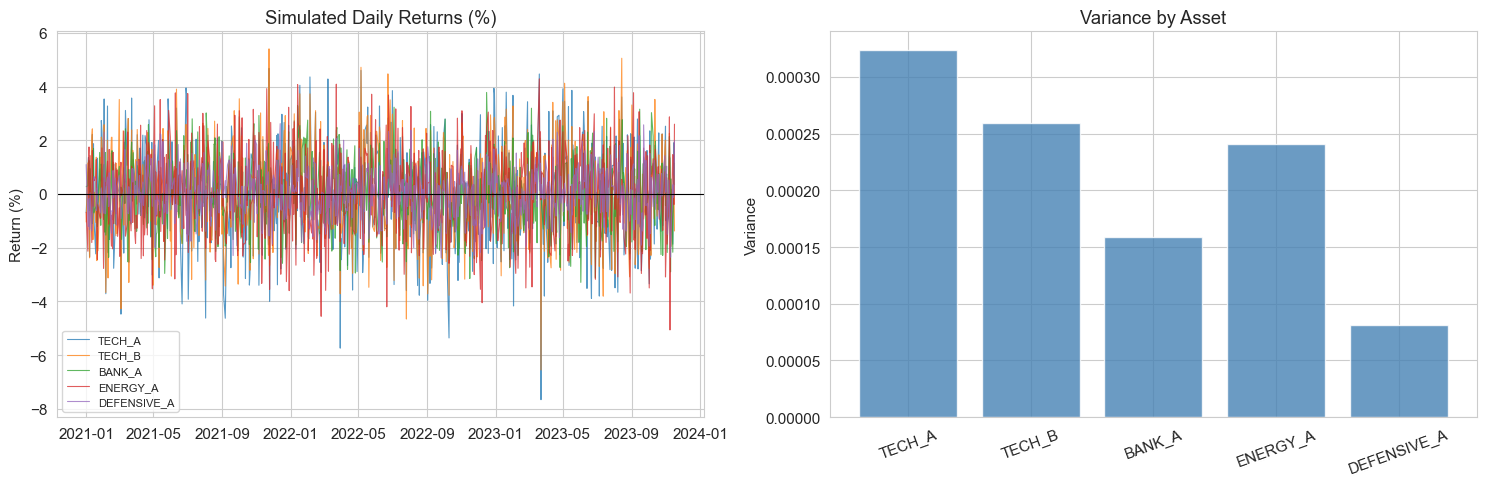

In [2]:
asset_names = ["TECH_A", "TECH_B", "BANK_A", "ENERGY_A", "DEFENSIVE_A"]
n_days = 750
dates = pd.bdate_range("2021-01-01", periods=n_days)

mean_returns = np.array([0.0006, 0.0005, 0.0004, 0.0003, 0.00025])
vols = np.array([0.018, 0.016, 0.013, 0.015, 0.009])
corr = np.array([
    [1.00, 0.82, 0.35, 0.20, 0.15],
    [0.82, 1.00, 0.30, 0.18, 0.12],
    [0.35, 0.30, 1.00, 0.28, 0.25],
    [0.20, 0.18, 0.28, 1.00, 0.40],
    [0.15, 0.12, 0.25, 0.40, 1.00],
])

cov_true = np.outer(vols, vols) * corr
returns = np.random.multivariate_normal(mean_returns, cov_true, size=n_days)
df_ret = pd.DataFrame(returns, index=dates, columns=asset_names)

variance_summary = pd.DataFrame({
    "Mean Return": df_ret.mean(),
    "Variance": df_ret.var(),
    "Std Dev": df_ret.std(),
}).round(6)

display(variance_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for col in df_ret.columns:
    axes[0].plot(df_ret.index, df_ret[col] * 100, linewidth=0.8, alpha=0.75, label=col)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Simulated Daily Returns (%)")
axes[0].set_ylabel("Return (%)")
axes[0].legend(fontsize=8)

axes[1].bar(variance_summary.index, variance_summary["Variance"], color="steelblue", alpha=0.8)
axes[1].set_title("Variance by Asset")
axes[1].set_ylabel("Variance")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 2. Covariance — How Two Assets Move Together

### Formal idea

For two return series $r_i$ and $r_j$, covariance is

$$\mathrm{Cov}(r_i, r_j)=\frac{1}{T-1}\sum_{t=1}^{T}(r_{i,t}-\bar r_i)(r_{j,t}-\bar r_j)$$

### Interpretation

- **Positive covariance**: the assets tend to move in the same direction
- **Negative covariance**: the assets tend to move in opposite directions
- **Near-zero covariance**: there is little linear co-movement

### Beginner explanation

Variance describes one asset by itself. Covariance describes a relationship between two assets.

This is important because diversification depends on relationships, not just on individual risk. Two risky assets can still make a portfolio safer if they do not move together too closely.

### When to use covariance

Use covariance when your question is about **how assets interact** rather than how one asset behaves alone.

Typical use cases:

- building a covariance matrix for portfolio risk
- checking whether two assets help diversify each other
- computing portfolio variance
- identifying pairs, sectors, or groups of assets that move together

A practical rule is: if your question is about **co-movement between return series**, covariance is the right tool.

,TECH_A,TECH_B,BANK_A,ENERGY_A,DEFENSIVE_A
TECH_A,0.000324,0.000236,0.000072,0.000059,0.000022
TECH_B,0.000236,0.000259,0.000053,0.000043,0.000013
BANK_A,0.000072,0.000053,0.000159,0.000058,0.000029
ENERGY_A,0.000059,0.000043,0.000058,0.000241,0.000068
DEFENSIVE_A,0.000022,0.000013,0.000029,0.000068,0.000081


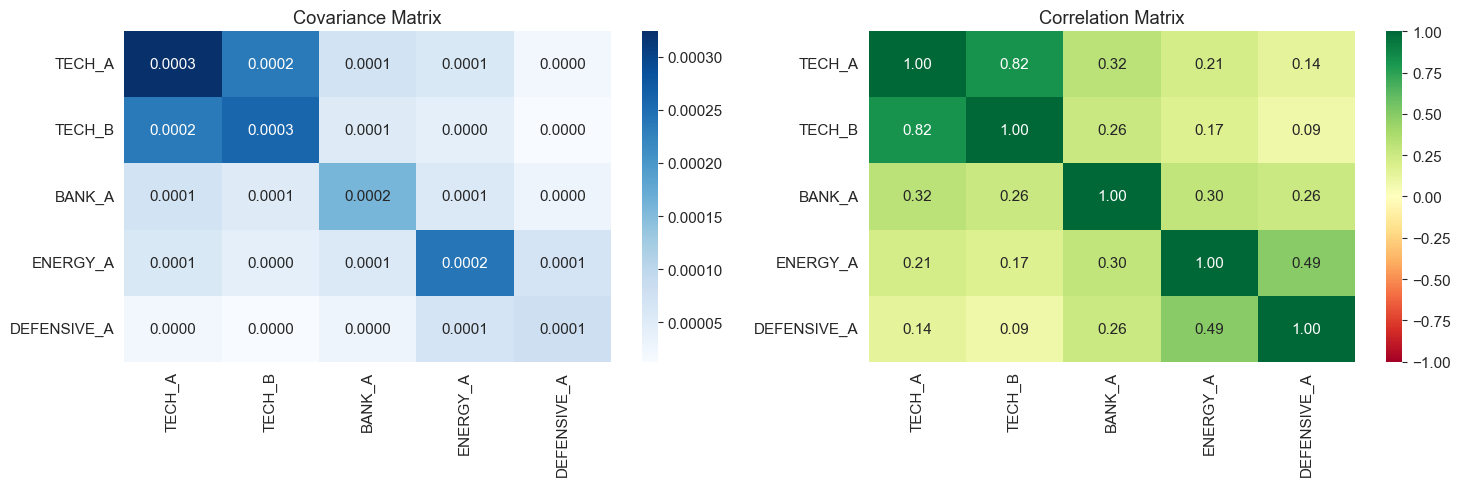

In [3]:
cov_matrix = df_ret.cov()
corr_matrix = df_ret.corr()

display(cov_matrix.round(6))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cov_matrix, annot=True, fmt=".4f", cmap="Blues", ax=axes[0])
axes[0].set_title("Covariance Matrix")

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlGn", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlation Matrix")

plt.tight_layout()
plt.show()

## 3. Why Covariance Matters for Portfolios

For a portfolio with weights $w$, the variance is

$$\sigma_p^2 = w^\top \Sigma w$$

where $\Sigma$ is the covariance matrix.

### Beginner explanation

This formula says portfolio risk is not just about each asset's own variance. It also depends on how the assets interact with each other.

That is why covariance is so important in portfolio construction. If two assets move together strongly, diversification is weaker. If they move differently, diversification improves.

Equal-weight portfolio variance: 0.000095
Equal-weight portfolio volatility: 0.0097


,Equal Weight,Asset Volatility
TECH_A,0.2,0.0180
TECH_B,0.2,0.0161
BANK_A,0.2,0.0126
ENERGY_A,0.2,0.0155
DEFENSIVE_A,0.2,0.0090


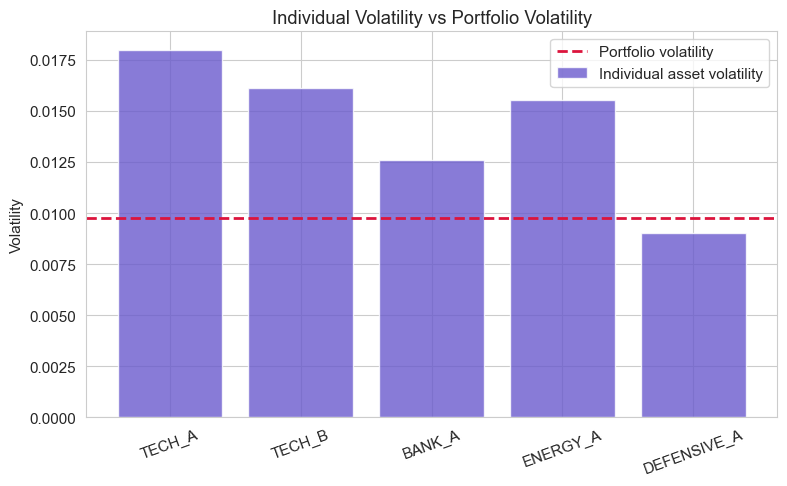

In [4]:
weights = np.repeat(1 / len(asset_names), len(asset_names))
portfolio_variance = weights @ cov_matrix.values @ weights
portfolio_vol = np.sqrt(portfolio_variance)

asset_vols = df_ret.std()
portfolio_summary = pd.DataFrame({
    "Equal Weight": weights,
    "Asset Volatility": asset_vols.values,
}, index=asset_names)

print(f"Equal-weight portfolio variance: {portfolio_variance:.6f}")
print(f"Equal-weight portfolio volatility: {portfolio_vol:.4f}")
display(portfolio_summary.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(asset_names, asset_vols.values, alpha=0.8, color="slateblue", label="Individual asset volatility")
ax.axhline(portfolio_vol, color="crimson", linestyle="--", linewidth=2, label="Portfolio volatility")
ax.set_title("Individual Volatility vs Portfolio Volatility")
ax.set_ylabel("Volatility")
ax.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4. Volatility Ratio and Thresholds

A simple way to compare assets is with a **volatility ratio**:

$$\text{Volatility Ratio}_i = \frac{\sigma_i}{\sigma_p}$$

where $\sigma_i$ is the asset volatility and $\sigma_p$ is the portfolio volatility.

### Beginner explanation

This ratio tells you how volatile each asset is relative to the whole portfolio.

- A ratio **above 1.0** means the asset is more volatile than the portfolio
- A ratio **below 1.0** means the asset is less volatile than the portfolio

### How volatility ratio is calculated from returns

Start from returns, not prices.

1. Take the return series for one asset: $r_{i,1}, r_{i,2}, ..., r_{i,T}$.
2. Compute the asset volatility as the standard deviation of those returns:

$$\sigma_i = \sqrt{\frac{1}{T-1}\sum_{t=1}^{T}(r_{i,t}-\bar r_i)^2}$$

3. Build the portfolio return series. For portfolio weights $w_1, ..., w_n$, each portfolio return is:

$$r_{p,t} = \sum_{j=1}^{n} w_j r_{j,t}$$

4. Compute the portfolio volatility from that portfolio return series:

$$\sigma_p = \sqrt{\frac{1}{T-1}\sum_{t=1}^{T}(r_{p,t}-\bar r_p)^2}$$

5. Divide asset volatility by portfolio volatility:

$$\text{Volatility Ratio}_i = \frac{\sigma_i}{\sigma_p}$$

So the volatility ratio is really a **relative standard deviation based on returns**.

### When to use volatility ratio

Use volatility ratio when you want to compare a single asset's risk with the portfolio benchmark around it.

Typical use cases:

- checking which assets dominate portfolio risk
- identifying assets that are much more volatile than the portfolio
- creating simple threshold-based alerts
- communicating relative risk in a way that is easier to interpret than raw variance alone

A practical rule is: if your question is **"how risky is this asset relative to the portfolio?"**, volatility ratio is very useful.

### Threshold idea

In this notebook we use a simple teaching interpretation:

- **Ratio < 0.8**: low relative volatility
- **0.8 to 1.2**: close to portfolio volatility
- **> 1.2**: high relative volatility

These thresholds are practical teaching rules, not universal laws. In real portfolio monitoring, thresholds are usually set using historical behavior, risk limits, or stress testing.

,Asset Volatility,Portfolio Volatility,Volatility Ratio,Threshold Label
TECH_A,0.0180,0.0097,1.8479,High
TECH_B,0.0161,0.0097,1.6532,High
BANK_A,0.0126,0.0097,1.2944,High
ENERGY_A,0.0155,0.0097,1.5925,High
DEFENSIVE_A,0.0090,0.0097,0.9240,Near Portfolio


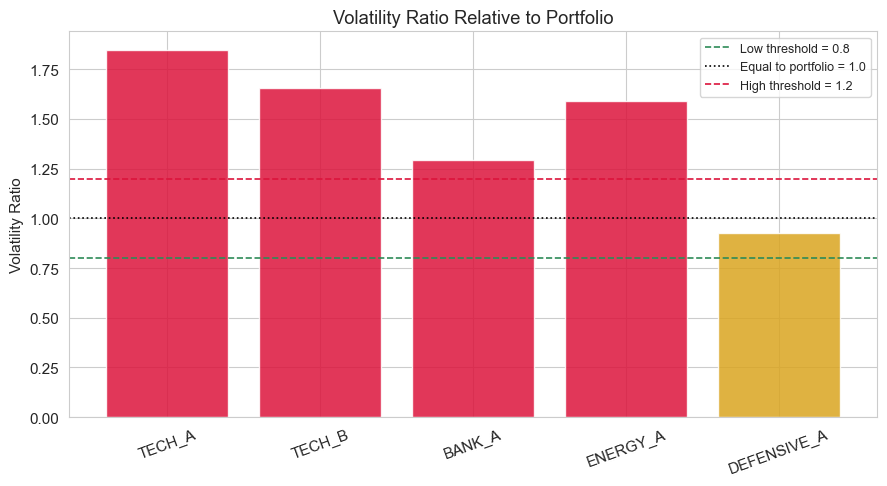

In [6]:
vol_ratio = asset_vols / portfolio_vol

def classify_vol_ratio(value):
    if value < 0.8:
        return "Low"
    if value <= 1.2:
        return "Near Portfolio"
    return "High"

vol_ratio_df = pd.DataFrame({
    "Asset Volatility": asset_vols,
    "Portfolio Volatility": portfolio_vol,
    "Volatility Ratio": vol_ratio,
    "Threshold Label": vol_ratio.map(classify_vol_ratio),
}).round(4)

display(vol_ratio_df)

fig, ax = plt.subplots(figsize=(9, 5))
colors = vol_ratio_df["Threshold Label"].map({
    "Low": "seagreen",
    "Near Portfolio": "goldenrod",
    "High": "crimson",
})

ax.bar(vol_ratio_df.index, vol_ratio_df["Volatility Ratio"], color=colors, alpha=0.85)
ax.axhline(0.8, color="seagreen", linestyle="--", linewidth=1.2, label="Low threshold = 0.8")
ax.axhline(1.0, color="black", linestyle=":", linewidth=1.2, label="Equal to portfolio = 1.0")
ax.axhline(1.2, color="crimson", linestyle="--", linewidth=1.2, label="High threshold = 1.2")
ax.set_title("Volatility Ratio Relative to Portfolio")
ax.set_ylabel("Volatility Ratio")
ax.legend(fontsize=9)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 4. Distance-Based Clustering of Assets

Clustering is a way to group assets that behave similarly. To do that, we first need a notion of **distance**.

A common finance choice is to convert correlation into distance using

$$d_{ij} = \sqrt{0.5(1-\rho_{ij})}$$

This formula has an intuitive meaning:

- if correlation is close to **1**, distance is small
- if correlation is close to **0**, distance is moderate
- if correlation is negative, distance becomes larger

### Beginner explanation

Clustering helps turn a large matrix into a simpler picture. Instead of reading every pairwise relationship one by one, you can ask: which assets naturally belong together?

That is useful for portfolio construction, diversification analysis, and risk visualization.

,Asset,Cluster
0,DEFENSIVE_A,1
1,ENERGY_A,1
2,TECH_A,2
3,TECH_B,2
4,BANK_A,3


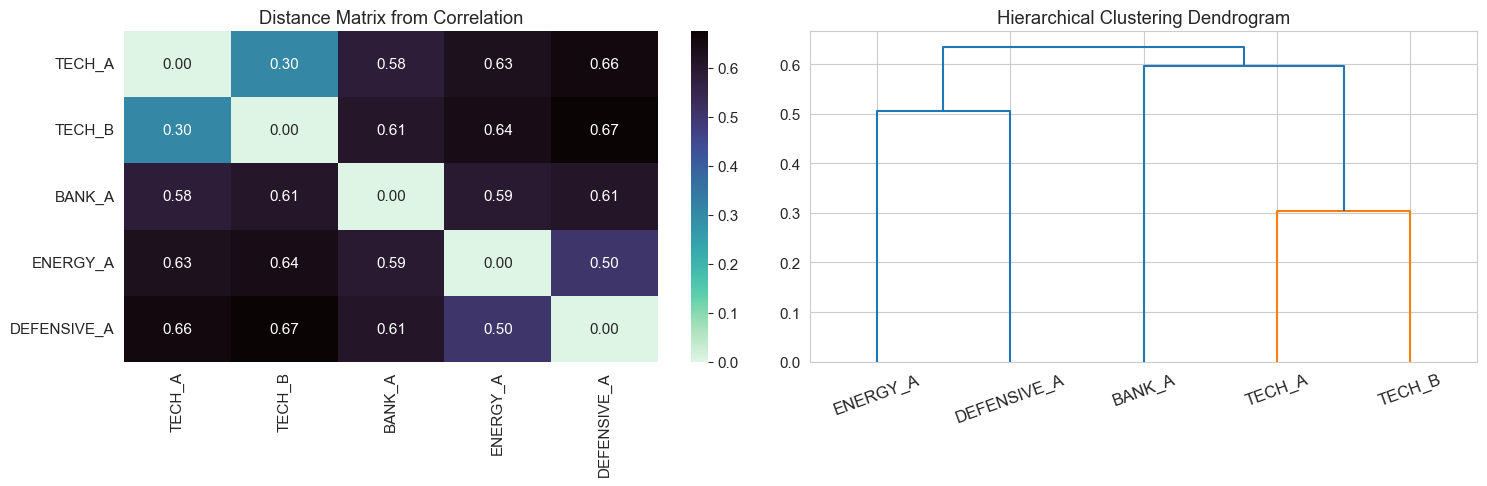

Cluster assignments:
  DEFENSIVE_A: Cluster 1
  ENERGY_A: Cluster 1
  TECH_A: Cluster 2
  TECH_B: Cluster 2
  BANK_A: Cluster 3


In [5]:
distance_matrix = np.sqrt(0.5 * (1 - corr_matrix))
np.fill_diagonal(distance_matrix.values, 0.0)

condensed_distance = squareform(distance_matrix.values, checks=False)
linkage_matrix = linkage(condensed_distance, method="average")
cluster_labels = fcluster(linkage_matrix, t=3, criterion="maxclust")

cluster_df = pd.DataFrame({
    "Asset": asset_names,
    "Cluster": cluster_labels,
}).sort_values(["Cluster", "Asset"]).reset_index(drop=True)

display(cluster_df)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.heatmap(distance_matrix, annot=True, fmt=".2f", cmap="mako_r", ax=axes[0])
axes[0].set_title("Distance Matrix from Correlation")

dendrogram(linkage_matrix, labels=asset_names, ax=axes[1], color_threshold=None)
axes[1].set_title("Hierarchical Clustering Dendrogram")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

print("Cluster assignments:")
for _, row in cluster_df.iterrows():
    print(f"  {row['Asset']}: Cluster {row['Cluster']}")

## 5. Final Takeaways

- **Variance** measures the spread of one asset's returns
- **Covariance** measures how two assets move together
- **Portfolio risk** depends on both individual asset risk and co-movement
- **Distance-based clustering** turns co-movement into groups of similar assets

### Beginner takeaway

If you remember one thing, remember this: in portfolio theory, risk is not only about how risky each asset is by itself. It is also about how assets behave together. Covariance is the bridge from single-asset risk to portfolio risk, and clustering is a practical way to visualize that structure.